In [1]:
import mne

# Sostituisci con uno dei tuoi percorsi validi:
gdf_file = '/Users/giuseppebonomo/Desktop/RatioWaveNet/BCI2b_IV/dataset/B0104E.gdf'  

# Carica in modalità non‑preload (più veloce per l’ispezione)
raw = mne.io.read_raw_gdf(gdf_file, preload=False, verbose=False)

# Metodo 1: stampa direttamente la lista dei nomi
print("Canali (raw.ch_names):")
print(raw.ch_names)

# Metodo 2: oppure dal dizionario info
print("\nCanali (raw.info['ch_names']):")
print(raw.info['ch_names'])


Canali (raw.ch_names):
['EEG:C3', 'EEG:Cz', 'EEG:C4', 'EOG:ch01', 'EOG:ch02', 'EOG:ch03']

Canali (raw.info['ch_names']):
['EEG:C3', 'EEG:Cz', 'EEG:C4', 'EOG:ch01', 'EOG:ch02', 'EOG:ch03']


/var/folders/_7/r_r3pscs7s52j4fc3jqjmv3w0000gn/T/ipykernel_23518/2697807931.py:7: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(gdf_file, preload=False, verbose=False)


/var/folders/_7/r_r3pscs7s52j4fc3jqjmv3w0000gn/T/ipykernel_23518/2747708263.py:21: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(gdf, preload=True, verbose=False)
/var/folders/_7/r_r3pscs7s52j4fc3jqjmv3w0000gn/T/ipykernel_23518/2747708263.py:21: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(gdf, preload=True, verbose=False)


✅ CSV salvato: bci2b_s9_E_mwl_04E05E_windows.csv


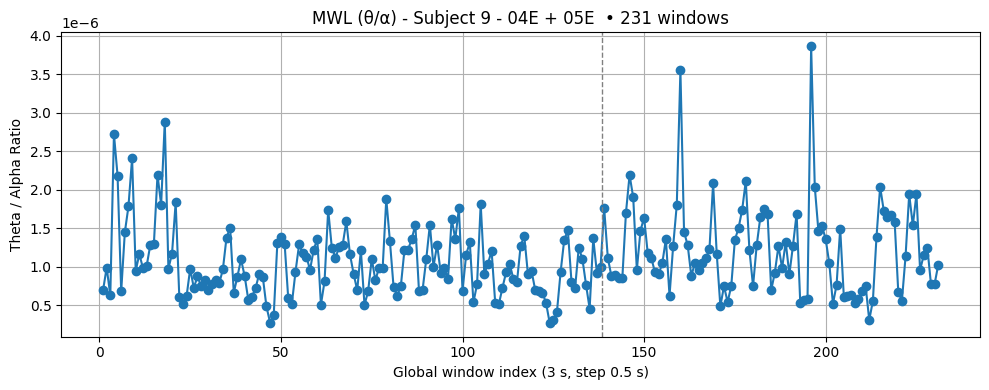

In [2]:
# %%  Estrai θ/α (3 s window, step 0.5 s) – con true_label

import os, glob, mne, numpy as np, pandas as pd
from scipy.signal import welch
import matplotlib.pyplot as plt

def mwl_windows_eval_bci2b(dataset_dir, subject,
                           channel_kw='cz',
                           tmin=0.5, tmax=4.5,
                           win_sec=3.0, step_sec=0.5,
                           theta_band=(4,7), alpha_band=(8,12)):

    patt  = os.path.join(dataset_dir, f"B{subject:02d}0[45]E.gdf")   # 04E/05E
    files = sorted(glob.glob(patt))
    if not files:
        raise FileNotFoundError(f"No 04E/05E files for subject {subject}")

    recs = []
    for gdf in files:
        run_id = os.path.basename(gdf).replace('.gdf','')
        raw = mne.io.read_raw_gdf(gdf, preload=True, verbose=False)
        raw.filter(0.5, 45, fir_design='firwin', verbose=False)
        raw.notch_filter(50, verbose=False)

        cz_name = next(ch for ch in raw.ch_names if channel_kw in ch.lower())

        # --- eventi MI -----------------------------------------------------
        events, event_id = mne.events_from_annotations(raw, verbose=False)
        mi_id = {k:v for k,v in event_id.items() if v in (1,2)}
        sel   = np.isin(events[:,2], list(mi_id.values()))
        events = events[sel]

        epochs = mne.Epochs(raw, events, event_id=mi_id,
                            picks=[cz_name], tmin=tmin, tmax=tmax,
                            baseline=None, preload=True, verbose=False)

        data   = epochs.get_data()[:,0,:]      # trials × samples
        labels = epochs.events[:,2]            # 1=Left, 2=Right
        fs     = raw.info['sfreq']
        win_s, step_s = int(win_sec*fs), int(step_sec*fs)

        for tr_i, sig in enumerate(data, 1):
            true_lbl = 0 if labels[tr_i-1]==1 else 1   # 0=Left, 1=Right
            for w, st in enumerate(range(0, len(sig)-win_s+1, step_s), 1):
                seg = sig[st:st+win_s]
                f,P = welch(seg, fs=fs, nperseg=int(fs*2))
                th  = np.trapz(P[(f>=theta_band[0])&(f<=theta_band[1])])
                al  = np.trapz(P[(f>=alpha_band[0])&(f<=alpha_band[1])])
                recs.append({'subject':subject,
                             'run':run_id,
                             'trial':tr_i,
                             'win_idx':w,
                             'theta_alpha':th/(al+1e-6),
                             'true_label':true_lbl})
    df = (pd.DataFrame(recs)
            .sort_values(['run','trial','win_idx'])
            .reset_index(drop=True))
    df['global_win'] = np.arange(1, len(df)+1)
    return df


# ---------- PARAMETRI ----------
dataset_dir = '/Users/giuseppebonomo/Desktop/RatioWaveNet/BCI2b_IV/dataset'
subject     = 9
# --------------------------------

df_mwl = mwl_windows_eval_bci2b(dataset_dir, subject)

csv_out = f"bci2b_s{subject}_E_mwl_04E05E_windows.csv"
df_mwl.to_csv(csv_out, index=False)
print("✅ CSV salvato:", csv_out)

# ---------- Plot stile richiesto ---------------------------------
ratios   = df_mwl['theta_alpha'].values
n_points = len(ratios)
last_04  = df_mwl[df_mwl['run'].str.endswith('4E')]['global_win'].max()

plt.figure(figsize=(10,4))
plt.plot(np.arange(1, n_points+1), ratios, marker='o')
plt.axvline(last_04 + 0.5, ls='--', color='gray', lw=1)   # separa 04E/05E
plt.title(f"MWL (θ/α) - Subject {subject} - 04E + 05E  • {n_points} windows")
plt.xlabel("Global window index (3 s, step 0.5 s)")
plt.ylabel("Theta / Alpha Ratio")
plt.grid(True)
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd

df = pd.read_csv('bci2b_s9_E_mwl_04E05E_windows.csv')
print(df[['theta_alpha']].describe())
# group by class label (0=left, 1=right, 2=foot, 3=tongue)
print(df.groupby('true_label')['theta_alpha'].agg(['mean','median','std','count']))


        theta_alpha
count  2.310000e+02
mean   1.112527e-06
std    5.199218e-07
min    2.698889e-07
25%    7.459741e-07
50%    9.906996e-07
75%    1.357575e-06
max    3.864371e-06
                mean        median           std  count
true_label                                             
0           0.000001  9.998381e-07  5.229855e-07    225
1           0.000001  9.308857e-07  4.102443e-07      6


✅ CSV salvato in: bci2b_sub9_results.csv
✅ Grafico salvato in: bci2b_sub9_plot.png


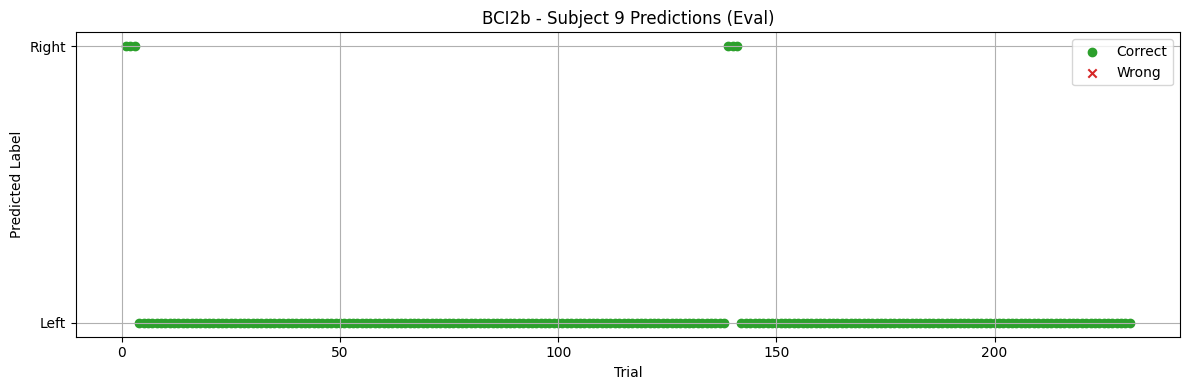

In [4]:
# %% Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# %% Funzione per analizzare true vs pred per BCI2b
def analyze_preds_bci2b(data_dir, subject,
                        true_fname, pred_fname,
                        output_csv, output_png):
    """
    data_dir:      cartella contenente i .npy
    subject:       integer soggetto (per titolo e label)
    true_fname:    nome file .npy con true labels, shape=(n_trials,)
    pred_fname:    nome file .npy con pred labels, shape=(n_trials,)
    output_csv:    path in cui salvare CSV di trial,true_label,pred_label
    output_png:    path in cui salvare il plot
    """
    # 1) Path completi
    true_path = os.path.join(data_dir, true_fname)
    pred_path = os.path.join(data_dir, pred_fname)

    # 2) Caricamento
    y_true = np.load(true_path)
    y_pred = np.load(pred_path)
    if y_true.shape != y_pred.shape:
        raise ValueError(f"Shape mismatch: true {y_true.shape} vs pred {y_pred.shape}")

    n_trials = len(y_true)

    # 3) DataFrame
    df = pd.DataFrame({
        'trial':      np.arange(1, n_trials+1),
        'true_label': y_true,
        'pred_label': y_pred
    })

    # 4) CSV
    os.makedirs(os.path.dirname(output_csv) or '.', exist_ok=True)
    df.to_csv(output_csv, index=False)
    print(f"✅ CSV salvato in: {output_csv}")

    # 5) Plot
    correct = df['true_label'] == df['pred_label']
    trials  = df['trial']
    preds   = df['pred_label']

    plt.figure(figsize=(12,4))
    plt.scatter(trials[correct], preds[correct],
                c='tab:green', marker='o', label='Correct')
    plt.scatter(trials[~correct], preds[~correct],
                c='tab:red', marker='x', label='Wrong')
    plt.title(f"BCI2b - Subject {subject} Predictions (Eval)")
    plt.xlabel("Trial")
    plt.ylabel("Predicted Label")
    plt.yticks([0, 1], ['Left', 'Right'])
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()

    # 6) Save figure
    os.makedirs(os.path.dirname(output_png) or '.', exist_ok=True)
    plt.savefig(output_png)
    print(f"✅ Grafico salvato in: {output_png}")
    plt.show()

# %% Chiamata per un singolo soggetto
data_dir   = "/Users/giuseppebonomo/Desktop/RatioWaveNet/CASPER_RatioWaveNet/commands/BCI2b"
subject    = 9
true_fname = f"BCI2b_sub{subject}_true.npy"   # es. BCI2b_sub1_true.npy
pred_fname = f"BCI2b_sub{subject}_cmds.npy"   # es. BCI2b_sub1_cmds.npy
output_csv = f"bci2b_sub{subject}_results.csv"
output_png = f"bci2b_sub{subject}_plot.png"

analyze_preds_bci2b(data_dir, subject,
                    true_fname, pred_fname,
                    output_csv, output_png)


✅ CSV combinato salvato: bci2b_sub9_combined.csv
✅ Grafico salvato: bci2b_sub9_combined_plot.png


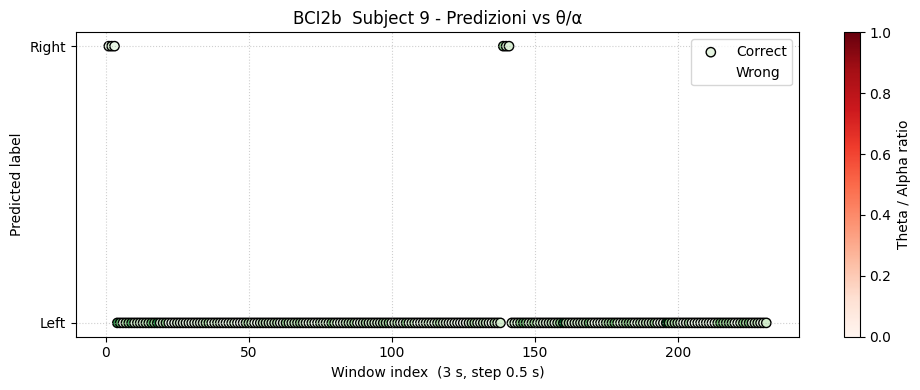

In [5]:
# %%  COMBINA predizioni + MWL  (BCI2b Evaluation, run 04E+05E)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- PARAMETRI ----------
subj          = 9                                  # soggetto
pred_csv      = Path(f"bci2b_sub{subj}_results.csv")            # 282 righe
mwl_csv       = Path(f"bci2b_s{subj}_E_mwl_04E05E_windows.csv") # 282 righe
out_comb_csv  = Path(f"bci2b_sub{subj}_combined.csv")
out_plot_png  = Path(f"bci2b_sub{subj}_combined_plot.png")
# --------------------------------

# 1) carica i due DataFrame ----------------------------------------------
df_pred = pd.read_csv(pred_csv)    # colonne trial,true_label,pred_label  (282)
df_mwl  = pd.read_csv(mwl_csv)     # colonne theta_alpha … (282)

# 2) crea indice globale finestra se non esiste --------------------------
df_pred['win_global'] = np.arange(1, len(df_pred)+1)
if 'global_win' in df_mwl.columns:
    df_mwl.rename(columns={'global_win':'win_global'}, inplace=True)
else:
    df_mwl['win_global'] = np.arange(1, len(df_mwl)+1)

# 3) merge ---------------------------------------------------------------
combined = pd.merge(df_pred,
                    df_mwl[['win_global','theta_alpha','true_label']],
                    on='win_global', how='inner')

combined.to_csv(out_comb_csv, index=False)
print("✅ CSV combinato salvato:", out_comb_csv)

# 4) plot verde/rosso ----------------------------------------------------
corr = combined['true_label_x'] == combined['pred_label']
wg   = combined['win_global']
rat  = combined['theta_alpha']
pred = combined['pred_label']

plt.figure(figsize=(10,4))
plt.scatter(wg[corr], pred[corr],
            c=rat[corr], cmap='Greens', marker='o', edgecolor='k',
            s=45, label='Correct')
plt.scatter(wg[~corr], pred[~corr],
            c=rat[~corr], cmap='Reds', marker='x', linewidths=1.5,
            s=70, label='Wrong')

plt.title(f"BCI2b  Subject {subj} - Predizioni vs θ/α")
plt.xlabel("Window index  (3 s, step 0.5 s)")
plt.ylabel("Predicted label")
plt.yticks([0,1], ['Left','Right'])
plt.colorbar(label='Theta / Alpha ratio')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

plt.savefig(out_plot_png, dpi=150)
print("✅ Grafico salvato:", out_plot_png)
plt.show()


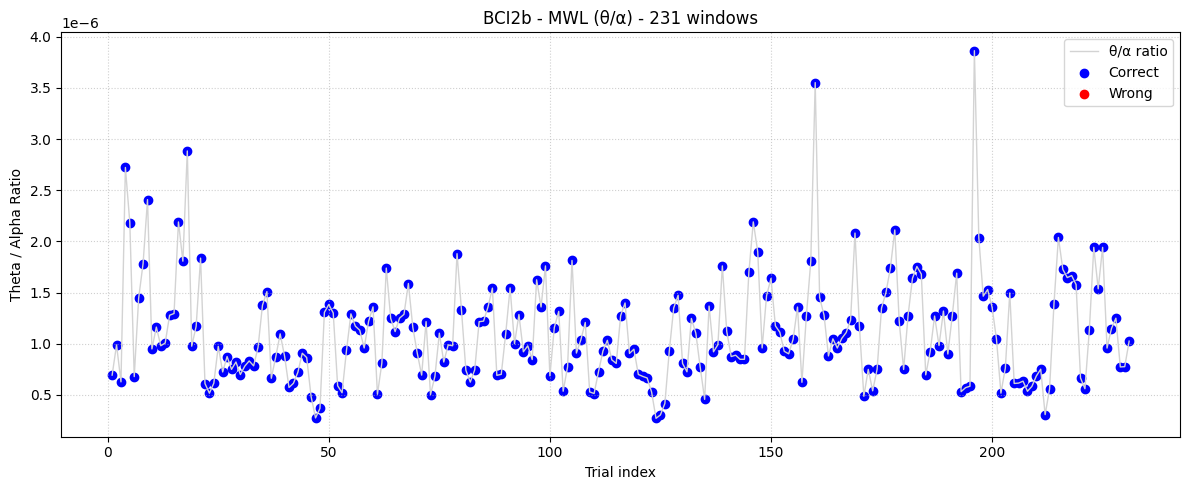

In [6]:
# %%  Plot con frecce e label per BCI2b  (2 classi Left/Right)

import numpy as np
import matplotlib.pyplot as plt

# ---------- DataFrame già caricato -----------------
# combined_df deve contenere:
#   • trial  (o global_win)        -> asse X
#   • theta_alpha                  -> asse Y
#   • true_label, pred_label       -> classi 0/1
# ---------------------------------------------------

# 1) scegli l’asse X
x_col = 'global_win' if 'global_win' in combined.columns else 'trial'
x_vals = combined[x_col].values
ratios = combined['theta_alpha'].values
true   = combined['true_label_x'].values
preds  = combined['pred_label'].values

# 2) maschere corretto / errato
wrong_mask   = preds != true
wrong_x      = x_vals[wrong_mask]
wrong_ratios = ratios[wrong_mask]
true_wrong   = true [wrong_mask]
pred_wrong   = preds[wrong_mask]

class_names = {0: 'Left', 1: 'Right'}   # BCI2b ha solo due classi
n_points    = x_vals.max()

fig, ax = plt.subplots(figsize=(12,5))

# linea θ/α
ax.plot(x_vals, ratios, color='lightgray', linewidth=1, label='θ/α ratio')

# scatter corrette / errate
ax.scatter(x_vals[~wrong_mask], ratios[~wrong_mask],
           c='blue', marker='o', label='Correct')
ax.scatter(wrong_x, wrong_ratios,
           c='red', marker='o', label='Wrong')

# livelli per posizionare le label sotto il grafico
cycle  = [1,2,3,4]                    # ripete 4 livelli
levels = {1:-0.15, 2:-0.25, 3:-0.35, 4:-0.45}

ymin, ymax = ax.get_ylim()
yrange     = ymax - ymin

# frecce e testi per ogni errore
for i, (x, y, tl, pl) in enumerate(zip(wrong_x, wrong_ratios,
                                       true_wrong, pred_wrong)):
    lvl   = cycle[i % len(cycle)]
    y_txt = ymin + levels[lvl]*yrange

    # freccia verticale
    ax.annotate('', xy=(x,y), xycoords='data',
                xytext=(x, y_txt), textcoords='data',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

    # true label (blu) – a sinistra
    ax.text(x-0.3, y_txt, class_names[tl],
            color='blue', fontsize=9, ha='right', va='center')

    # pred label (rosso) – a destra
    ax.text(x+0.3, y_txt, class_names[pl],
            color='red', fontsize=9, ha='left', va='center')

# rifiniture
ax.set_title(f"BCI2b - MWL (θ/α) - {n_points} windows")
ax.set_xlabel("Window index" if x_col=='global_win' else "Trial index")
ax.set_ylabel("Theta / Alpha Ratio")
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()
